In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns

In [4]:
df = pd.read_csv("credit_risk_dataset.csv")

In [5]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
print("Number of rows and columns:")
print(df.shape)

Number of rows and columns:
(32581, 12)


In [7]:
print("Dataset Columns:")
print(df.columns.tolist())

Dataset Columns:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


In [8]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 2.5 MB


In [9]:
print("Statistical Description:")
df.describe()

Statistical Description:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [10]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [11]:
print("Loan Status Distribution:")
print(df["loan_status"].value_counts())

Loan Status Distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64


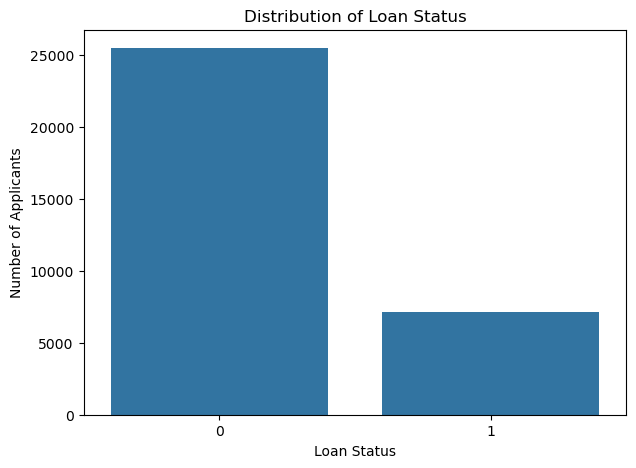

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="loan_status")

plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.show()

In [13]:
# Interpretation:
# The target variable distribution shows the number of applicants
# belonging to each loan-status category. A comparison of the two
# categories helps determine whether the dataset is balanced or
# imbalanced. If one category has considerably more observations
# than the other, class imbalance should be considered during model
# evaluation.

Numerical Columns:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']


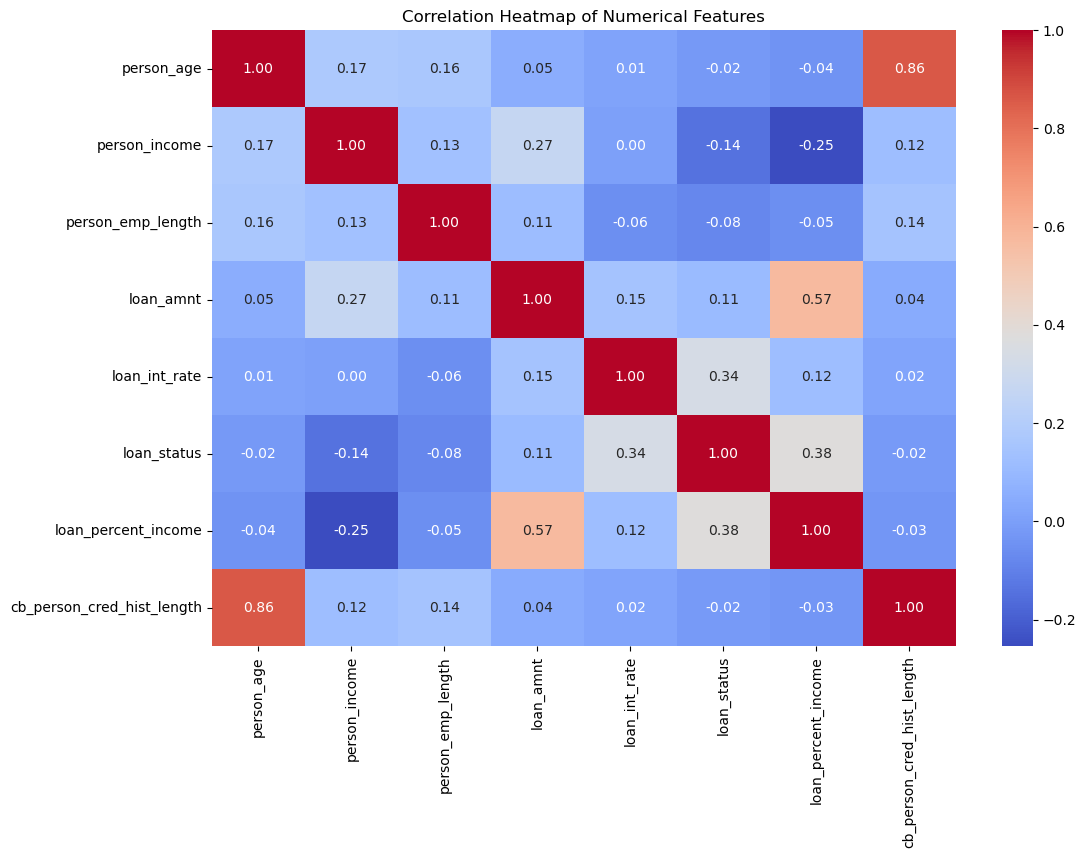

In [13]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [17]:
# Interpretation:
# The correlation heatmap shows the strength and direction of the relationships
# between the numerical variables. The strongest positive correlation is between
# person_age and cb_person_cred_hist_length (0.86), indicating that older
# applicants generally tend to have longer credit histories. There is also a
# moderate positive correlation between loan_amnt and loan_percent_income (0.57),
# while loan_status has a moderate positive correlation with loan_percent_income
# (0.38) and loan_int_rate (0.34). Person_income has a moderate negative
# correlation with loan_percent_income (-0.25). Most of the remaining
# relationships are relatively weak, with correlation values close to zero.
# Overall, the heatmap shows that several numerical features have limited
# linear relationships with the target variable, while the strong relationship
# between age and credit history length should be considered when developing
# the machine learning model.

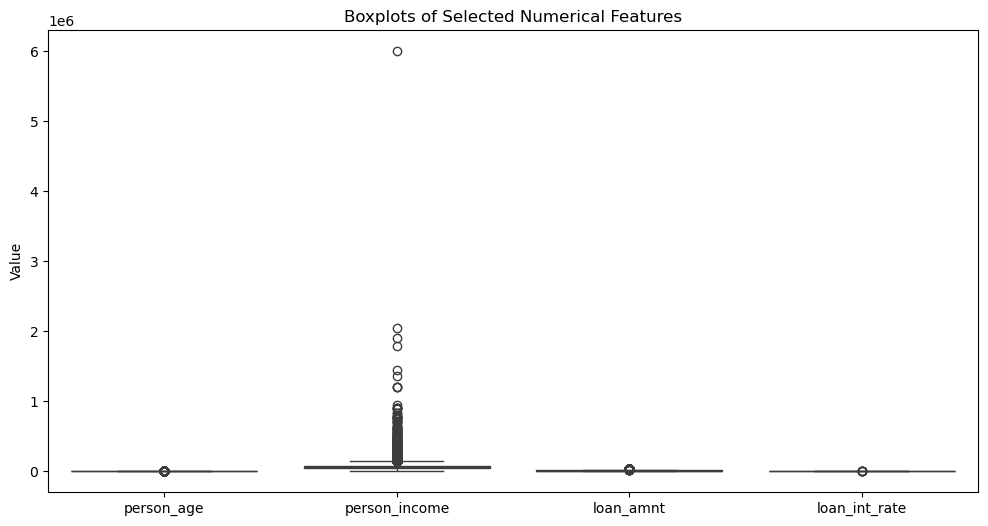

In [15]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[
        ["person_age",
         "person_income",
         "loan_amnt",
         "loan_int_rate"]
    ]
)

plt.title("Boxplots of Selected Numerical Features")
plt.ylabel("Value")

plt.show()

In [16]:
# Interpretation:
# The boxplots show the presence of potential outliers in the selected
# numerical features. Person_income contains the largest number of
# extreme values, including several observations with very high income.
# Person_age, loan_amnt, and loan_int_rate also contain potential
# outliers, although their distributions are compressed because of the
# much larger income values. These outliers will be investigated and
# treated during the data-cleaning and preprocessing stage.

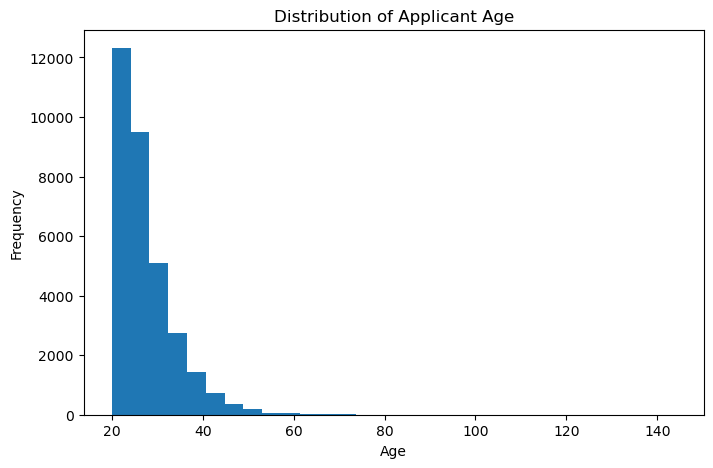

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["person_age"],
    bins=30
)

plt.title("Distribution of Applicant Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [101]:
# Interpretation: There is a significant right-skew in the age distribution. 
#Young individuals make up the bulk of loan applicants (peak between the ages of 20 and 30), with a steep decline in frequency beyond the age of 40. 
#There are extremely few applicants who are older than 60 or 70, and there are a few extreme outliers (those who are older than 100), which are either exceptional cases or data errors. 
#This skewness suggests that the younger cohort will dominate age-related risk patterns and supports the adoption of robust scaling and median imputation.

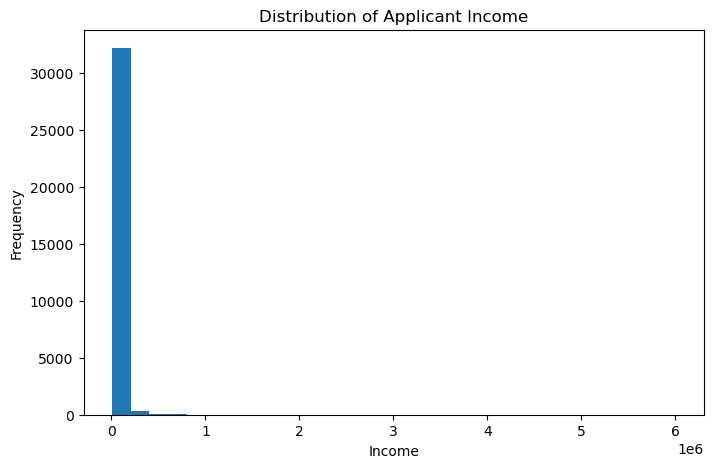

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["person_income"],
    bins=30
)

plt.title("Distribution of Applicant Income")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

In [102]:
# Interpretation: There is a significant right-skew in the applicant income distribution. 
#While a tiny percentage of applicants have extremely high earnings (up to several million), the great majority of applicants have relatively low incomes (concentrated around the lower end of the scale). 
#Income should be handled carefully during preprocessing (e.g., median imputation if lacking, outlier capping, and obligatory feature scaling) in order to prevent high-income values from dominating distance-based models and PCA, as indicated by the extreme outliers and heavy skewness.


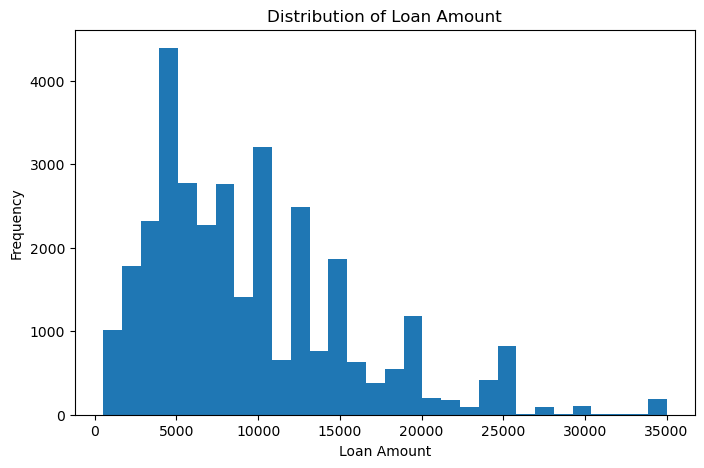

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["loan_amnt"],
    bins=30
)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

In [103]:
# Interpretation: There are several peaks in the right-skewed loan amount distribution. 
#The majority of loans fall into the lower to mid range (about 5,000 to 15,000), with frequency decreasing as loan amounts rise. 
#Few applicants are demanding the maximum sums close to 35,000, and there are fewer large loans beyond 25,000. 
#This pattern indicates that loan amount is a significant risk factor and should be scaled # prior to using PCA and distance-based algorithms (k-NN).

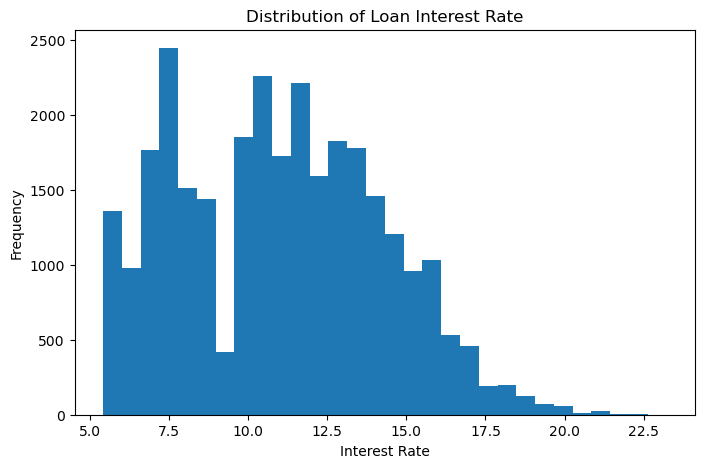

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["loan_int_rate"].dropna(),
    bins=30
)

plt.title("Distribution of Loan Interest Rate")
plt.xlabel("Interest Rate")
plt.ylabel("Frequency")

plt.show()

In [104]:
# Interpretation: There are several peaks in the interest rate distribution, which is rather right-skewed.
#Interest rates on the majority of loans are concentrated between roughly 7% and 14%, with two notable peaks at 7–8% and 10–12.5%.
#Very high rates (>20%) are uncommon, and higher rates (over 15–17%) become increasingly uncommon. 
#This distribution shows that interest rates are important risk indicators that should be appropriately scaled before modeling because they have a direct impact on the likelihood of default.

In [21]:
df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Copy created successfully.")

Original dataset shape: (32581, 12)
Copy created successfully.


In [22]:
print("Missing values before treatment:")
print(df_clean.isnull().sum())

# Identify numerical columns.
numerical_columns = df_clean.select_dtypes(
    include=np.number
).columns

# Replace missing numerical values with the median of each column.
for column in numerical_columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].median()
        )

print("Missing values after numerical imputation:")
print(df_clean.isnull().sum())

categorical_columns = df_clean.select_dtypes(
    include="object"
).columns

print("Categorical columns:")
print(categorical_columns.tolist())

print("\nMissing categorical values:")
print(df_clean[categorical_columns].isnull().sum())

# Replace missing categorical values with the most frequent category.
for column in categorical_columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].mode()[0]
        )

print("Missing values after categorical imputation:")
print(df_clean.isnull().sum())

# Final check to confirm that missing values have been handled.
print("Total remaining missing values:")
print(df_clean.isnull().sum().sum())

Missing values before treatment:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64
Missing values after numerical imputation:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


<ipython-input-22-d10f6ebf0f48>:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_clean.select_dtypes(


Categorical columns:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Missing categorical values:
person_home_ownership        0
loan_intent                  0
loan_grade                   0
cb_person_default_on_file    0
dtype: int64
Missing values after categorical imputation:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64
Total remaining missing values:
0


In [23]:
print("Number of duplicate rows:")
print(df_clean.duplicated().sum())

# Remove duplicate records to prevent repeated observations
# from influencing the machine learning models more than once.

df_clean = df_clean.drop_duplicates()

print("Dataset shape after removing duplicates:")
print(df_clean.shape)

# Justification:
# Duplicate records are removed because identical observations
# could give repeated cases more influence during model training
# and may therefore affect the reliability of the model.

Number of duplicate rows:
165
Dataset shape after removing duplicates:
(32416, 12)


In [24]:
print("Cleaned Dataset:")
display(df_clean.head())

print("Cleaned Dataset Shape:")
print(df_clean.shape)

Cleaned Dataset:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Cleaned Dataset Shape:
(32416, 12)


In [25]:
# Separate the predictor variables from the target variable.
# My target is the loan_status

X = df_clean.drop("loan_status", axis=1)
y = df_clean["loan_status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (32416, 11)
Target shape: (32416,)


In [111]:
# Separate features and target
X = df_clean.drop("loan_status", axis=1)
y = df_clean["loan_status"]

# Identify categorical variables
categorical_columns = X.select_dtypes(include=['str', 'category']).columns

print("Categorical variables:")
print(categorical_columns)


X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

print("Shape after categorical encoding:")
print(X.shape)

display(X.head())

Categorical variables:
Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='str')
Shape after categorical encoding:
(32416, 22)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,0.59,3,False,False,True,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0.10,2,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,0.57,3,False,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,0.53,2,False,False,True,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,0.55,4,False,False,True,...,True,False,False,False,True,False,False,False,False,True


In [112]:
print("Data types after encoding:")
print(X.dtypes)

Data types after encoding:
person_age                       int64
person_income                    int64
person_emp_length              float64
loan_amnt                        int64
loan_int_rate                  float64
loan_percent_income            float64
cb_person_cred_hist_length       int64
person_home_ownership_OTHER       bool
person_home_ownership_OWN         bool
person_home_ownership_RENT        bool
loan_intent_EDUCATION             bool
loan_intent_HOMEIMPROVEMENT       bool
loan_intent_MEDICAL               bool
loan_intent_PERSONAL              bool
loan_intent_VENTURE               bool
loan_grade_B                      bool
loan_grade_C                      bool
loan_grade_D                      bool
loan_grade_E                      bool
loan_grade_F                      bool
loan_grade_G                      bool
cb_person_default_on_file_Y       bool
dtype: object


In [113]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (25932, 22)
Testing feature shape: (6484, 22)
Training target shape: (25932,)
Testing target shape: (6484,)


In [114]:
numerical_features = X_train.select_dtypes(
    include=np.number
).columns

print("Numerical features:")
print(numerical_features.tolist())



for column in numerical_features:

    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X_train[column] = X_train[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    X_test[column] = X_test[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outlier treatment completed.")

# Justification:
# The IQR method is used to reduce the influence of extreme
# observations identified during EDA. Instead of deleting the
# observations, extreme values are capped at the IQR boundaries.
# This preserves the records while reducing the influence of
# unusually large or small values.

Numerical features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
Outlier treatment completed.


In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

# Feature scaling explanation:
#Because the numerical variables in the dataset have varying ranges, feature scaling is required. For instance, variables like interest rate and age have considerably limited numerical ranges, whereas person_income # might have values in the thousands or millions.
#Without scaling, algorithms that rely on numerical magnitudes or distances may be disproportionately affected by variables with bigger numerical values. StandardScaler adjusts the characteristics to have a similar size. This is especially crucial for Logistic Regression, where feature magnitudes can influence model optimization, and K-Nearest Neighbors (KNN), which uses the distances between observations.
#To avoid data leakage, the scaler is only fitted to the training data before being applied to the test data.

Feature scaling completed.


In [117]:
print("FINAL DATASET INFORMATION")
print("--------------------------")
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

FINAL DATASET INFORMATION
--------------------------
Training features: (25932, 22)
Testing features: (6484, 22)
Training target: (25932,)
Testing target: (6484,)


In [33]:
#check if the scaled data do exist.
X_train_scaled
X_test_scaled
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (25932, 22)
Testing data shape: (6484, 22)


In [34]:
from sklearn.decomposition import PCA

pca = PCA()

X_train_pca_full = pca.fit_transform(X_train_scaled)
X_test_pca_full = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of PCA components:", X_train_pca_full.shape[1])

Original number of features: 22
Number of PCA components: 22


In [35]:
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
for i, variance in enumerate(explained_variance, start=1):
    print(f"Principal Component {i}: {variance:.4f} ({variance * 100:.2f}%)")

Explained Variance Ratio:
Principal Component 1: 0.1039 (10.39%)
Principal Component 2: 0.0950 (9.50%)
Principal Component 3: 0.0760 (7.60%)
Principal Component 4: 0.0710 (7.10%)
Principal Component 5: 0.0584 (5.84%)
Principal Component 6: 0.0557 (5.57%)
Principal Component 7: 0.0548 (5.48%)
Principal Component 8: 0.0536 (5.36%)
Principal Component 9: 0.0520 (5.20%)
Principal Component 10: 0.0498 (4.98%)
Principal Component 11: 0.0477 (4.77%)
Principal Component 12: 0.0460 (4.60%)
Principal Component 13: 0.0459 (4.59%)
Principal Component 14: 0.0451 (4.51%)
Principal Component 15: 0.0411 (4.11%)
Principal Component 16: 0.0379 (3.79%)
Principal Component 17: 0.0247 (2.47%)
Principal Component 18: 0.0212 (2.12%)
Principal Component 19: 0.0087 (0.87%)
Principal Component 20: 0.0056 (0.56%)
Principal Component 21: 0.0032 (0.32%)
Principal Component 22: 0.0027 (0.27%)


Cumulative Explained Variance:
1 components: 0.1039 (10.39%)
2 components: 0.1989 (19.89%)
3 components: 0.2749 (27.49%)
4 components: 0.3458 (34.58%)
5 components: 0.4042 (40.42%)
6 components: 0.4599 (45.99%)
7 components: 0.5147 (51.47%)
8 components: 0.5683 (56.83%)
9 components: 0.6203 (62.03%)
10 components: 0.6702 (67.02%)
11 components: 0.7178 (71.78%)
12 components: 0.7639 (76.39%)
13 components: 0.8098 (80.98%)
14 components: 0.8549 (85.49%)
15 components: 0.8959 (89.59%)
16 components: 0.9338 (93.38%)
17 components: 0.9586 (95.86%)
18 components: 0.9798 (97.98%)
19 components: 0.9885 (98.85%)
20 components: 0.9941 (99.41%)
21 components: 0.9973 (99.73%)
22 components: 1.0000 (100.00%)


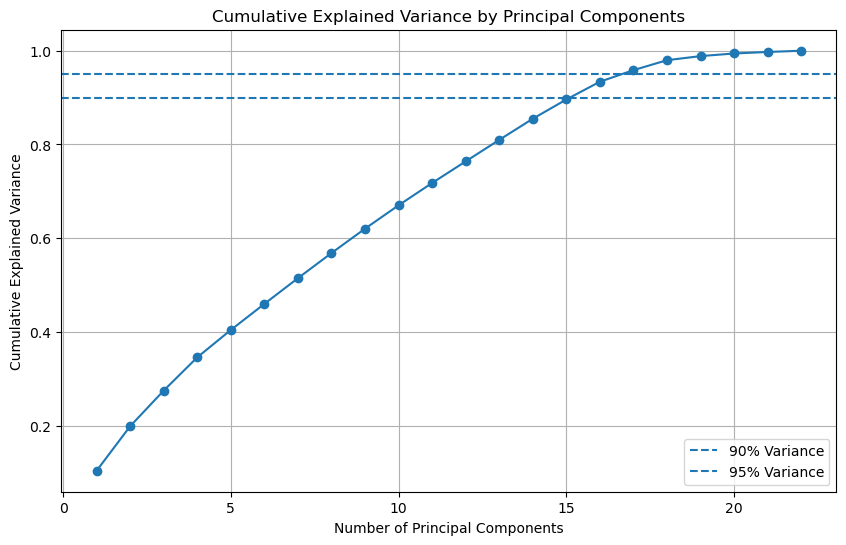

In [36]:
cumulative_variance = np.cumsum(explained_variance)

print("Cumulative Explained Variance:")
for i, variance in enumerate(cumulative_variance, start=1):
    print(f"{i} components: {variance:.4f} ({variance * 100:.2f}%)")

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% Variance"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by Principal Components")

plt.legend()
plt.grid()
plt.show()

In [37]:
# the 90% Variance
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(
    "Number of components required for at least 90% variance:",
    n_components_90
)

print(
    "Variance captured:",
    f"{cumulative_variance[n_components_90 - 1] * 100:.2f}%"
)

#for 95 Variance

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(
    "Number of components required for at least 95% variance:",
    n_components_95
)

print(
    "Variance captured:",
    f"{cumulative_variance[n_components_95 - 1] * 100:.2f}%"
)

Number of components required for at least 90% variance: 16
Variance captured: 93.38%
Number of components required for at least 95% variance: 17
Variance captured: 95.86%


In [38]:
n_components = 17

n_components = n_components_95

print("Selected number of PCA components:", n_components)
print(
    "Variance retained:",
    f"{cumulative_variance[n_components - 1] * 100:.2f}%"
)

Selected number of PCA components: 17
Variance retained: 95.86%


In [39]:
#Creating the final Pca model.

pca_final = PCA(n_components=n_components)

X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print("Original training data shape:", X_train_scaled.shape)
print("PCA training data shape:", X_train_pca.shape)

print("Original testing data shape:", X_test_scaled.shape)
print("PCA testing data shape:", X_test_pca.shape)

#Transform the dataset

pca_columns = [
    f"PC{i}"
    for i in range(1, n_components + 1)
]

X_train_pca_df = pd.DataFrame(
    X_train_pca,
    columns=pca_columns
)

X_test_pca_df = pd.DataFrame(
    X_test_pca,
    columns=pca_columns
)

print("PCA Training Dataset:")
display(X_train_pca_df.head())

#Adding the target variable

pca_train_dataset = X_train_pca_df.copy()
pca_train_dataset["loan_status"] = y_train.values

pca_test_dataset = X_test_pca_df.copy()
pca_test_dataset["loan_status"] = y_test.values

print("PCA training dataset:")
display(pca_train_dataset.head())

Original training data shape: (25932, 22)
PCA training data shape: (25932, 17)
Original testing data shape: (6484, 22)
PCA testing data shape: (6484, 17)
PCA Training Dataset:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17
0,-0.980545,-1.580266,-0.630181,-0.249802,-0.875522,-1.713584,-1.036977,1.218286,-0.690288,0.118387,-0.149746,0.155487,-0.143732,-0.144302,-0.957332,-1.333668,0.821784
1,2.906074,-0.092223,1.968182,-0.113816,-0.761925,2.883388,-0.952852,1.260182,-0.484847,-0.099389,-1.079357,-0.079196,-0.341489,0.036011,0.166459,1.118513,0.642682
2,-1.039533,0.064215,-1.495066,1.116476,-0.393224,-1.300807,-1.600407,1.094083,-0.327285,0.039594,0.032589,0.208762,-0.205476,-0.032596,-1.075125,-1.306968,0.468576
3,-1.962114,1.857892,-0.300143,-2.656675,-1.319352,-0.373451,0.940761,-0.606687,-0.093243,2.201126,-0.396987,-0.180917,0.123594,-0.086123,-0.838178,0.754270,0.549665
4,1.676169,0.387594,-0.260545,1.315536,-0.556648,-2.654487,-1.515035,-0.088661,1.082658,-0.542607,-0.862532,0.211774,-0.263719,-0.072076,-0.186047,-1.159684,0.323765


PCA training dataset:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,loan_status
0,-0.980545,-1.580266,-0.630181,-0.249802,-0.875522,-1.713584,-1.036977,1.218286,-0.690288,0.118387,-0.149746,0.155487,-0.143732,-0.144302,-0.957332,-1.333668,0.821784,0
1,2.906074,-0.092223,1.968182,-0.113816,-0.761925,2.883388,-0.952852,1.260182,-0.484847,-0.099389,-1.079357,-0.079196,-0.341489,0.036011,0.166459,1.118513,0.642682,1
2,-1.039533,0.064215,-1.495066,1.116476,-0.393224,-1.300807,-1.600407,1.094083,-0.327285,0.039594,0.032589,0.208762,-0.205476,-0.032596,-1.075125,-1.306968,0.468576,0
3,-1.962114,1.857892,-0.300143,-2.656675,-1.319352,-0.373451,0.940761,-0.606687,-0.093243,2.201126,-0.396987,-0.180917,0.123594,-0.086123,-0.838178,0.754270,0.549665,0
4,1.676169,0.387594,-0.260545,1.315536,-0.556648,-2.654487,-1.515035,-0.088661,1.082658,-0.542607,-0.862532,0.211774,-0.263719,-0.072076,-0.186047,-1.159684,0.323765,1


In [40]:
# Interpretation
#The scaled dataset was subjected to PCA in order to minimize the number of features while preserving the majority of the data.
#According to the analysis, 16 components were needed to capture 93.38% of the variation and keep at least 90% of the variance; 17 components were needed to attain at least 95% of the variance. 
#95.86% of the total variance is retained by the 17 chosen components. As a result, 17 main components were chosen for the final PCA-transformed dataset. 
#PCA preserved 95.86% of the variance while reducing the complexity of the feature space. 
#In the machine-learning phase, the PCA-transformed data will be compared to the original features.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Create the three required classification models.

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

print("All three models have been created.")

All three models have been created.


In [42]:
X_train_scaled
X_test_scaled

# Train Logistic Regression using the original scaled features.

logistic_model.fit(X_train_scaled, y_train)

logistic_original_pred = logistic_model.predict(X_test_scaled)

print("Logistic Regression trained using original features.")

Logistic Regression trained using original features.


In [43]:
# Evaluate Logistic Regression using original features.

logistic_original_accuracy = accuracy_score(
    y_test,
    logistic_original_pred
)

logistic_original_precision = precision_score(
    y_test,
    logistic_original_pred,
    zero_division=0
)

logistic_original_recall = recall_score(
    y_test,
    logistic_original_pred,
    zero_division=0
)

logistic_original_f1 = f1_score(
    y_test,
    logistic_original_pred,
    zero_division=0
)

print("LOGISTIC REGRESSION — ORIGINAL FEATURES")
print("----------------------------------------")
print("Accuracy :", logistic_original_accuracy)
print("Precision:", logistic_original_precision)
print("Recall   :", logistic_original_recall)
print("F1-score :", logistic_original_f1)

LOGISTIC REGRESSION — ORIGINAL FEATURES
----------------------------------------
Accuracy : 0.8702961135101789
Precision: 0.7688723205964585
Recall   : 0.581805359661495
F1-score : 0.6623845845042152


Confusion Matrix:
[[4839  227]
 [ 641  777]]


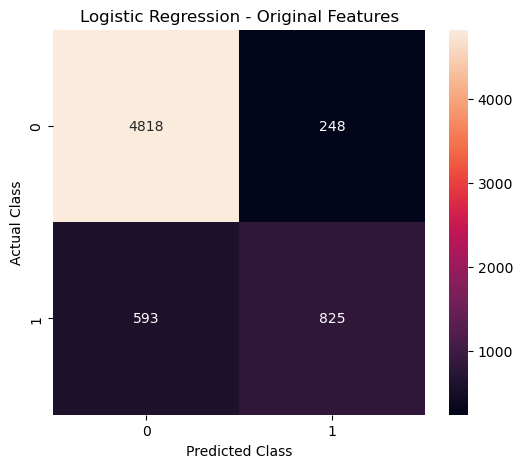

In [79]:
# Confusion Matrix for Logistic Regression using original features.

cm_logistic_pca = confusion_matrix(
    y_test,
    logistic_pca_pred
)

print("Confusion Matrix:")
print(cm_logistic_pca)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic_original,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression - Original Features")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [45]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        logistic_original_pred,
        zero_division=0
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5066
           1       0.77      0.58      0.66      1418

    accuracy                           0.87      6484
   macro avg       0.83      0.77      0.79      6484
weighted avg       0.86      0.87      0.86      6484



In [46]:
# Train KNN using the original scaled features.

knn_model.fit(X_train_scaled, y_train)

knn_original_pred = knn_model.predict(X_test_scaled)

print("KNN trained using original features.")

/lib/python3.14/site-packages/threadpoolctl.py:1135: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


KNN trained using original features.


In [47]:
# Evaluate KNN using original features.

knn_original_accuracy = accuracy_score(
    y_test,
    knn_original_pred
)

knn_original_precision = precision_score(
    y_test,
    knn_original_pred,
    zero_division=0
)

knn_original_recall = recall_score(
    y_test,
    knn_original_pred,
    zero_division=0
)

knn_original_f1 = f1_score(
    y_test,
    knn_original_pred,
    zero_division=0
)

print("KNN — ORIGINAL FEATURES")
print("-----------------------")
print("Accuracy :", knn_original_accuracy)
print("Precision:", knn_original_precision)
print("Recall   :", knn_original_recall)
print("F1-score :", knn_original_f1)

KNN — ORIGINAL FEATURES
-----------------------
Accuracy : 0.8946637877853177
Precision: 0.8516746411483254
Recall   : 0.6276445698166432
F1-score : 0.7226958993097848


KNN Confusion Matrix:
[[4911  155]
 [ 528  890]]


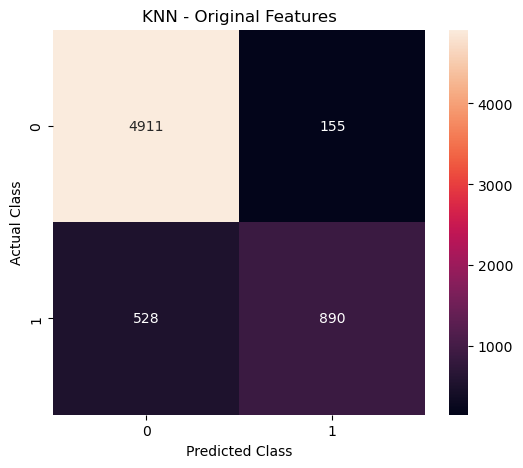

In [78]:
cm_knn_original = confusion_matrix(
    y_test,
    knn_original_pred
)

print("KNN Confusion Matrix:")
print(cm_knn_original)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn_original,
    annot=True,
    fmt="d"
)

plt.title("KNN - Original Features")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [49]:
print("KNN Classification Report:")
print(
    classification_report(
        y_test,
        knn_original_pred,
        zero_division=0
    )
)

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      5066
           1       0.85      0.63      0.72      1418

    accuracy                           0.89      6484
   macro avg       0.88      0.80      0.83      6484
weighted avg       0.89      0.89      0.89      6484



In [50]:
# Train Decision Tree using the original features.

decision_tree_model.fit(X_train_scaled, y_train)

tree_original_pred = decision_tree_model.predict(X_test_scaled)

print("Decision Tree trained using original features.")

Decision Tree trained using original features.


In [51]:
tree_original_accuracy = accuracy_score(
    y_test,
    tree_original_pred
)

tree_original_precision = precision_score(
    y_test,
    tree_original_pred,
    zero_division=0
)

tree_original_recall = recall_score(
    y_test,
    tree_original_pred,
    zero_division=0
)

tree_original_f1 = f1_score(
    y_test,
    tree_original_pred,
    zero_division=0
)

print("DECISION TREE — ORIGINAL FEATURES")
print("----------------------------------")
print("Accuracy :", tree_original_accuracy)
print("Precision:", tree_original_precision)
print("Recall   :", tree_original_recall)
print("F1-score :", tree_original_f1)

DECISION TREE — ORIGINAL FEATURES
----------------------------------
Accuracy : 0.892041949413942
Precision: 0.7406166219839142
Recall   : 0.7792665726375176
F1-score : 0.7594501718213058


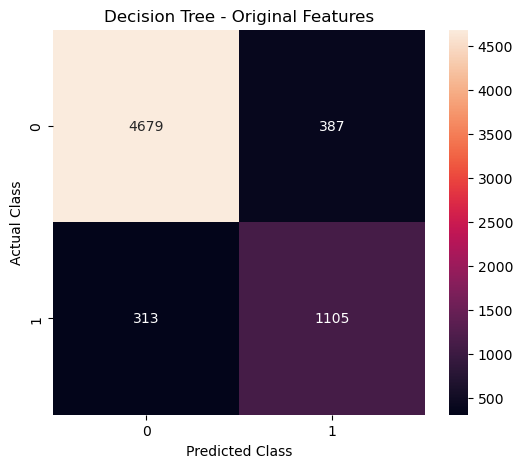

In [77]:
cm_tree_original = confusion_matrix(
    y_test,
    tree_original_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree_original,
    annot=True,
    fmt="d"
)

plt.title("Decision Tree - Original Features")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [53]:
print("Decision Tree Classification Report:")
print(
    classification_report(
        y_test,
        tree_original_pred,
        zero_division=0
    )
)

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      5066
           1       0.74      0.78      0.76      1418

    accuracy                           0.89      6484
   macro avg       0.84      0.85      0.84      6484
weighted avg       0.89      0.89      0.89      6484



In [54]:
logistic_pca_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_pca_model.fit(
    X_train_pca,
    y_train
)

logistic_pca_pred = logistic_pca_model.predict(
    X_test_pca
)

print("Logistic Regression trained using PCA features.")

Logistic Regression trained using PCA features.


In [55]:
logistic_pca_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_pca_model.fit(
    X_train_pca,
    y_train
)

logistic_pca_pred = logistic_pca_model.predict(
    X_test_pca
)

print("Logistic Regression trained using PCA features.")

Logistic Regression trained using PCA features.


In [56]:
logistic_pca_accuracy = accuracy_score(
    y_test,
    logistic_pca_pred
)

logistic_pca_precision = precision_score(
    y_test,
    logistic_pca_pred,
    zero_division=0
)

logistic_pca_recall = recall_score(
    y_test,
    logistic_pca_pred,
    zero_division=0
)

logistic_pca_f1 = f1_score(
    y_test,
    logistic_pca_pred,
    zero_division=0
)

print("LOGISTIC REGRESSION — PCA FEATURES")
print("-----------------------------------")
print("Accuracy :", logistic_pca_accuracy)
print("Precision:", logistic_pca_precision)
print("Recall   :", logistic_pca_recall)
print("F1-score :", logistic_pca_f1)

LOGISTIC REGRESSION — PCA FEATURES
-----------------------------------
Accuracy : 0.8661320172732881
Precision: 0.7739043824701195
Recall   : 0.5479548660084627
F1-score : 0.6416184971098265


Confusion Matrix:
[[4839  227]
 [ 641  777]]


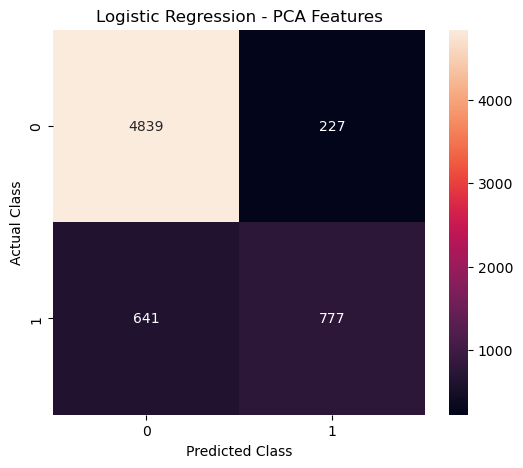

In [74]:
cm_logistic_pca = confusion_matrix(
    y_test,
    logistic_pca_pred
)

print("Confusion Matrix:")
print(cm_logistic_pca)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic_pca,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression - PCA Features")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [57]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        logistic_pca_pred,
        zero_division=0
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      5066
           1       0.77      0.55      0.64      1418

    accuracy                           0.87      6484
   macro avg       0.83      0.75      0.78      6484
weighted avg       0.86      0.87      0.86      6484



In [58]:
knn_pca_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_pca_model.fit(
    X_train_pca,
    y_train
)

knn_pca_pred = knn_pca_model.predict(
    X_test_pca
)

print("KNN trained using PCA features.")

KNN trained using PCA features.


In [59]:
knn_pca_accuracy = accuracy_score(
    y_test,
    knn_pca_pred
)

knn_pca_precision = precision_score(
    y_test,
    knn_pca_pred,
    zero_division=0
)

knn_pca_recall = recall_score(
    y_test,
    knn_pca_pred,
    zero_division=0
)

knn_pca_f1 = f1_score(
    y_test,
    knn_pca_pred,
    zero_division=0
)

print("KNN — PCA FEATURES")
print("-------------------")
print("Accuracy :", knn_pca_accuracy)
print("Precision:", knn_pca_precision)
print("Recall   :", knn_pca_recall)
print("F1-score :", knn_pca_f1)

KNN — PCA FEATURES
-------------------
Accuracy : 0.8955891425046267
Precision: 0.8511848341232228
Recall   : 0.6332863187588152
F1-score : 0.7262434290335624


KNN Confusion Matrix:
[[4909  157]
 [ 520  898]]


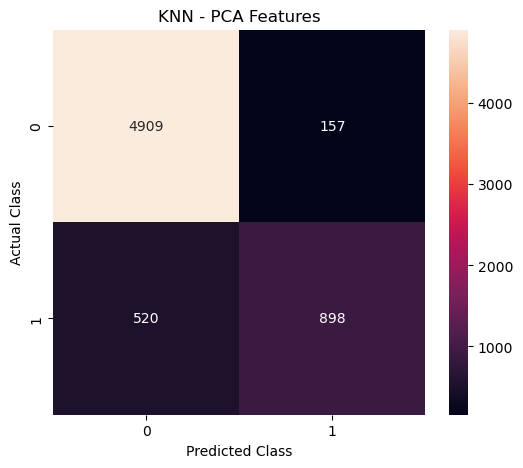

In [75]:
cm_knn_pca = confusion_matrix(
    y_test,
    knn_pca_pred
)

print("KNN Confusion Matrix:")
print(cm_knn_pca)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn_pca,
    annot=True,
    fmt="d"
)

plt.title("KNN - PCA Features")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [61]:
print("KNN Classification Report:")
print(
    classification_report(
        y_test,
        knn_pca_pred,
        zero_division=0
    )
)

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94      5066
           1       0.85      0.63      0.73      1418

    accuracy                           0.90      6484
   macro avg       0.88      0.80      0.83      6484
weighted avg       0.89      0.90      0.89      6484



In [62]:
tree_pca_model = DecisionTreeClassifier(
    random_state=42
)

tree_pca_model.fit(
    X_train_pca,
    y_train
)

tree_pca_pred = tree_pca_model.predict(
    X_test_pca
)

print("Decision Tree trained using PCA features.")

Decision Tree trained using PCA features.


In [63]:
tree_pca_accuracy = accuracy_score(
    y_test,
    tree_pca_pred
)

tree_pca_precision = precision_score(
    y_test,
    tree_pca_pred,
    zero_division=0
)

tree_pca_recall = recall_score(
    y_test,
    tree_pca_pred,
    zero_division=0
)

tree_pca_f1 = f1_score(
    y_test,
    tree_pca_pred,
    zero_division=0
)

print("DECISION TREE — PCA FEATURES")
print("-----------------------------")
print("Accuracy :", tree_pca_accuracy)
print("Precision:", tree_pca_precision)
print("Recall   :", tree_pca_recall)
print("F1-score :", tree_pca_f1)

DECISION TREE — PCA FEATURES
-----------------------------
Accuracy : 0.8429981492905614
Precision: 0.6366120218579235
Recall   : 0.6572637517630465
F1-score : 0.6467730742539903


Decision Tree Confusion Matrix:
[[4534  532]
 [ 486  932]]


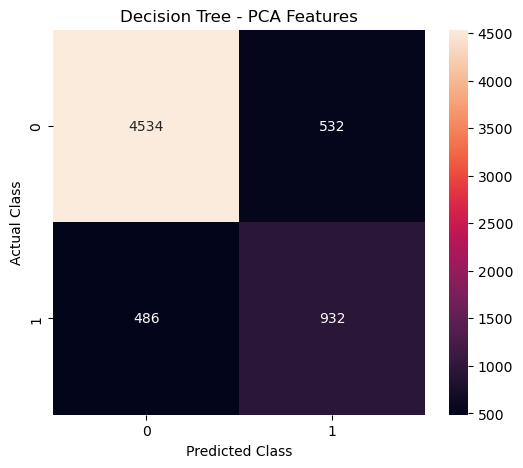

In [76]:
cm_tree_pca = confusion_matrix(
    y_test,
    tree_pca_pred
)

print("Decision Tree Confusion Matrix:")
print(cm_tree_pca)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree_pca,
    annot=True,
    fmt="d"
)

plt.title("Decision Tree - PCA Features")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [65]:
print("Decision Tree PCA Classification Report:")
print(
    classification_report(
        y_test,
        tree_pca_pred,
        zero_division=0
    )
)

Decision Tree PCA Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      5066
           1       0.64      0.66      0.65      1418

    accuracy                           0.84      6484
   macro avg       0.77      0.78      0.77      6484
weighted avg       0.84      0.84      0.84      6484



In [66]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],
    
    "Features": [
        "Original",
        "Original",
        "Original",
        "PCA",
        "PCA",
        "PCA"
    ],
    
    "Accuracy": [
        logistic_original_accuracy,
        knn_original_accuracy,
        tree_original_accuracy,
        logistic_pca_accuracy,
        knn_pca_accuracy,
        tree_pca_accuracy
    ],
    
    "Precision": [
        logistic_original_precision,
        knn_original_precision,
        tree_original_precision,
        logistic_pca_precision,
        knn_pca_precision,
        tree_pca_precision
    ],
    
    "Recall": [
        logistic_original_recall,
        knn_original_recall,
        tree_original_recall,
        logistic_pca_recall,
        knn_pca_recall,
        tree_pca_recall
    ],
    
    "F1-score": [
        logistic_original_f1,
        knn_original_f1,
        tree_original_f1,
        logistic_pca_f1,
        knn_pca_f1,
        tree_pca_f1
    ]
})

display(comparison.round(4))

,Model,Features,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Original,0.8703,0.7689,0.5818,0.6624
1,KNN,Original,0.8947,0.8517,0.6276,0.7227
2,Decision Tree,Original,0.8920,0.7406,0.7793,0.7595
3,Logistic Regression,PCA,0.8661,0.7739,0.5480,0.6416
4,KNN,PCA,0.8956,0.8512,0.6333,0.7262
5,Decision Tree,PCA,0.8430,0.6366,0.6573,0.6468


In [67]:
# Interpretation
#The findings demonstrate that the three machine-learning models performed differently when trained using the original features as opposed to the PCA-transformed features. 
#Logistic Regression obtained an accuracy of 87.03% and an F1-score of 66.24% for the original features. 
#KNN outperformed, with an accuracy of 89.47% and an F1-score of 72.27%. Among the original-feature models, 
#the Decision Tree # had the greatest F1-score at 75.95% and an accuracy of 89.20%. Additionally, it outperformed the other original-feature models in detecting positive loan-status cases, as seen by its greatest recall of 77.93%. 
#The performance of Logistic Regression somewhat declined once PCA was applied. Its #F1-score dropped from 66.24% to 64.16%, while its accuracy dropped from 87.03% to 86.61%. 
#This suggests that some predictive information for Logistic Regression was lost as a result of the dimensionality reduction. 
#KNN shown a slight improvement following PCA. Recall rose from 62.76% to 63.33%, accuracy from 89.47% to 89.56%, and F1-score from 72.27% to 72.62%. This implies that PCA has a somewhat favorable impact on KNN performance.
# After PCA, Decision Tree's performance declined the most. Its F1-score # dropped from 75.95% to 64.68%, and its accuracy dropped from 89.20% to 84.30%. Additionally, recall dropped from 77.93% to 65.73%. 
#This shows that the Decision Tree fared significantly better when utilizing the original features. Overall, KNN earned the best accuracy after PCA at 89.56%, but the Decision Tree using the original features achieved the highest recall (77.93%) and F1-score (75.95%). 
#Consequently, the Decision Tree with the original characteristics yielded the best overall classification performance based on the F1-score and recall. But out of all six model configurations, KNN with PCA had the best accuracy (89.56%). The comparison reveals that PCA did not improve all models equally. KNN saw a minor improvement, Logistic Regression saw a minor decline, and the Decision Tree saw a significant decline. 
#As a result, PCA's impact varies depending on the machine-learning method employed, therefore it shouldn't be taken for granted that it will enhance model performance.

In [80]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [81]:
# Creating the Decision Tree model for hyperparameter tuning.

dt_model = DecisionTreeClassifier(
    random_state=42
)

print("Decision Tree model created.")

Decision Tree model created.


In [82]:
# this are the hyperparameters that GridSearchCV will test on.

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

print("Hyperparameter grid created.")

Hyperparameter grid created.


In [83]:
# finding the best Decision Tree parameters using the GridSearchCV.

grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("GridSearchCV completed.")

GridSearchCV completed.


In [85]:
print("Best Parameters:")
print(grid_search.best_params_)

print(
    "Best Cross-Validation F1-score:",
    round(grid_search.best_score_, 4)
)

Best Parameters:
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best Cross-Validation F1-score: 0.8019


In [86]:
# Getting the best Decision Tree model found by GridSearchCV.

best_dt_model = grid_search.best_estimator_

print("Optimized Decision Tree obtained.")

Optimized Decision Tree obtained.


In [87]:
# Make predictions on the unseen test data.

dt_tuned_pred = best_dt_model.predict(X_test_scaled)

print("Predictions completed.")

Predictions completed.


In [90]:
#Calculating the Accuracy
dt_tuned_accuracy = accuracy_score(
    y_test,
    dt_tuned_pred
)

print("Tuned Decision Tree Accuracy:",
      round(dt_tuned_accuracy, 4))

Tuned Decision Tree Accuracy: 0.9266


In [91]:
#calculate the Precision

dt_tuned_precision = precision_score(
    y_test,
    dt_tuned_pred,
    zero_division=0
)

print("Tuned Decision Tree Precision:",
      round(dt_tuned_precision, 4))

Tuned Decision Tree Precision: 0.946


In [92]:
#Calculate the Recall
dt_tuned_recall = recall_score(
    y_test,
    dt_tuned_pred,
    zero_division=0
)

print("Tuned Decision Tree Recall:",
      round(dt_tuned_recall, 4))

Tuned Decision Tree Recall: 0.7045


In [93]:
#Calculate the f1_score
dt_tuned_f1 = f1_score(
    y_test,
    dt_tuned_pred,
    zero_division=0
)

print("Tuned Decision Tree F1-score:",
      round(dt_tuned_f1, 4))

Tuned Decision Tree F1-score: 0.8076


In [94]:
print("TUNED DECISION TREE RESULTS")
print("---------------------------")
print("Accuracy :", round(dt_tuned_accuracy, 4))
print("Precision:", round(dt_tuned_precision, 4))
print("Recall   :", round(dt_tuned_recall, 4))
print("F1-score :", round(dt_tuned_f1, 4))

TUNED DECISION TREE RESULTS
---------------------------
Accuracy : 0.9266
Precision: 0.946
Recall   : 0.7045
F1-score : 0.8076


Confusion Matrix:
[[5009   57]
 [ 419  999]]


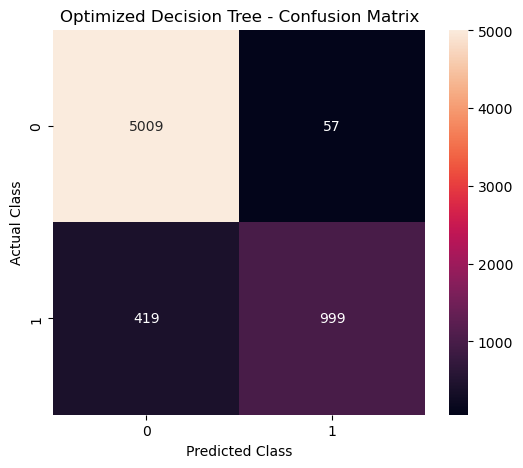

In [95]:
cm_dt_tuned = confusion_matrix(
    y_test,
    dt_tuned_pred
)

print("Confusion Matrix:")
print(cm_dt_tuned)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt_tuned,
    annot=True,
    fmt="d"
)

plt.title("Optimized Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [96]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        dt_tuned_pred,
        zero_division=0
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      5066
           1       0.95      0.70      0.81      1418

    accuracy                           0.93      6484
   macro avg       0.93      0.85      0.88      6484
weighted avg       0.93      0.93      0.92      6484



In [97]:
dt_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    
    "Before Tuning": [
        tree_original_accuracy,
        tree_original_precision,
        tree_original_recall,
        tree_original_f1
    ],
    
    "After Tuning": [
        dt_tuned_accuracy,
        dt_tuned_precision,
        dt_tuned_recall,
        dt_tuned_f1
    ]
})

display(dt_comparison.round(4))

,Metric,Before Tuning,After Tuning
0,Accuracy,0.8920,0.9266
1,Precision,0.7406,0.9460
2,Recall,0.7793,0.7045
3,F1-score,0.7595,0.8076


In [98]:
#Calculating the improvement
dt_improvement = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    
    "Change": [
        dt_tuned_accuracy - tree_original_accuracy,
        dt_tuned_precision - tree_original_precision,
        dt_tuned_recall - tree_original_recall,
        dt_tuned_f1 - tree_original_f1
    ]
})

display(dt_improvement.round(4))

,Metric,Change
0,Accuracy,0.0345
1,Precision,0.2054
2,Recall,-0.0748
3,F1-score,0.0481


In [99]:
# Interpreting Bias and Variance:
#The goal of model optimization is to strike a balance between variance and bias. While a model with high variance is too complex and may overfit the training data, a model with high bias is too simplistic and may underfit the data.
# Choice When trees are allowed to grow exceedingly deep, they can learn noise and very particular patterns from the training data, which can result in large variance. Excellent #training performance but subpar #unseen data performance may arise from this.
#GridSearchBy evaluating various # numbers for max_depth, min_samples_split, and min_samples_leaf, CV helps manage this issue.
# Limiting the tree's depth or needing additional observations for splits and leaf nodes can lower variance by reducing model complexity.
#However, if the tree is too simplistic, the model might not be able to identify significant patterns in the data, which could lead to an increase in bias.
#In order to improve generalization to unobserved data, the chosen hyperparameters seek to strike a balance between bias and variance.

In [100]:
# Concluding Remark:
#Among the models assessed in Part E, the Decision Tree with the original characteristics was chosen for optimization since it had the highest recall (77.93%) and F1-score (75.95%).
#Using GridSearchCV and 5-fold cross-validation, the optimal set of Decision Tree hyperparameters was found. 
#The optimal #parameters were min_samples_leaf=1, min_samples_split=5, max_depth=10, and criterion='gini'. The optimal cross-validation F1-score was 0.8019. 
#Prior to adjustment, the Decision Tree's accuracy was 89.20%, precision was 74.06%, recall was 77.93%, and F1-score was 75.95%. 
#Following tuning, the model's accuracy was 92.66%, its precision was 94.60%, its recall was 70.45%, and its F1-score was 80.76%. 
#The model's accuracy grew by 3.45 percentage points and its precision by 20.54 percentage points. 
#There was a 4.81 percentage point improvement in the F1-score as well. 
#Nevertheless, recall dropped by 7.48 percentage points, indicating that, in comparison to the initial Decision Tree, the modified model identified fewer good cases. 
#The adjusted Decision Tree outperformed the original in terms of accuracy, precision, and F1-score. 
#The F1-score increased from 75.95% to 80.76%, indicating that precision and recall were more balanced. 
#In a credit-risk classification problem, accurately identifying positive cases is also crucial, so the decrease in recall should be taken into account. 
#In terms of bias and variance, the original Decision Tree might have had higher variance because an unrestricted tree can become unduly complex and learn patterns unique to the training data. 
#GridSearchCV chose a minimum sample split of 5 and a maximum tree depth of 10, which limits the model's complexity. 
#The results indicate that hyperparameter adjustment generated a better balance between model complexity and prediction performance, which can assist minimize variance and increase generalization to unknown data. 
#The decline in ever, indicates that not all evaluation metrics saw the same improvement.